# 线性回归

### 正规方程

In [4]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# 加载加利福尼亚房价数据集
california = fetch_california_housing(data_home='./data')
# 转换为 DataFrame，方便查看
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

# 显示前5行数据
print(df.head())
# 显示数据集的基本信息
print(df.info())
# 显示描述性统计信息
print(df.describe())

print("数据集的形状:", df.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 no

In [6]:
# 分割训练集和测试集，避免模型训练和评估出现数据泄漏
from sklearn.model_selection import train_test_split

# 选择特征变量X和目标变量y
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 将数据分为训练集和测试集（例如80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化特征：让每个特征的均值为0，方差为1，有助于提高模型表现
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 在训练集上拟合，并对训练集标准化
X_test_scaled = scaler.transform(X_test)        # 用相同的缩放参数对测试集标准化

# 通过线性回归的“正规方程”解法直接求解最优参数
# 正规方程公式: θ = (X^T X)^(-1) X^T y
import numpy as np

# 增加截距项（偏置项），即在特征最前面加一列1
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]  # 训练集特征加一列1
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]     # 测试集特征加一列1

# 计算正规方程，得到最优的θ参数
# np.dot 和 @ 在二维数组/矩阵的情景下是等价的，都代表矩阵乘法。这里可以用 @ 运算符替换 dot 方法：
theta_best = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

# 用训练得到的参数进行预测
y_pred = X_test_b.dot(theta_best)

# 简单评估模型的表现（均方误差）
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
# 计算训练集上的预测结果和均方误差
y_train_pred = X_train_b.dot(theta_best)
mse_train = mean_squared_error(y_train, y_train_pred)
print("正规方程：训练集均方误差(MSE)：", mse_train)
print("正规方程：测试集均方误差(MSE)：", mse)

# 正规方程说明：
# 正规方程是一种不需要迭代、可以直接求解线性回归模型最优参数的解析方法。
# 它利用如下公式直接计算参数θ，使损失函数最小：
#      θ = (X^T X)^(-1) X^T y
# 其中，X是样本特征矩阵，y是真实标签向量。
# 该方法仅适用于特征数量不是特别巨大的情况，因计算逆矩阵很耗时。

正规方程：训练集均方误差(MSE)： 0.5179331255246699
正规方程：测试集均方误差(MSE)： 0.5558915986952441


In [7]:
from sklearn.linear_model import LinearRegression

# 初始化线性回归模型
lin_reg = LinearRegression()

# 在训练集上拟合模型
lin_reg.fit(X_train_scaled, y_train)

# 用模型对训练集和测试集进行预测
y_train_pred_sklearn = lin_reg.predict(X_train_scaled)
y_test_pred_sklearn = lin_reg.predict(X_test_scaled)

# 计算训练集和测试集的均方误差(MSE)
mse_train_sklearn = mean_squared_error(y_train, y_train_pred_sklearn)
mse_test_sklearn = mean_squared_error(y_test, y_test_pred_sklearn)

print("sklearn线性回归：训练集均方误差(MSE)：", mse_train_sklearn)
print("sklearn线性回归：测试集均方误差(MSE)：", mse_test_sklearn)

sklearn线性回归：训练集均方误差(MSE)： 0.5179331255246699
sklearn线性回归：测试集均方误差(MSE)： 0.5558915986952444


梯度下降法找到的最小值x为: 0.00013292279957849163
此时y最小值为: 1.7668470647783856e-08


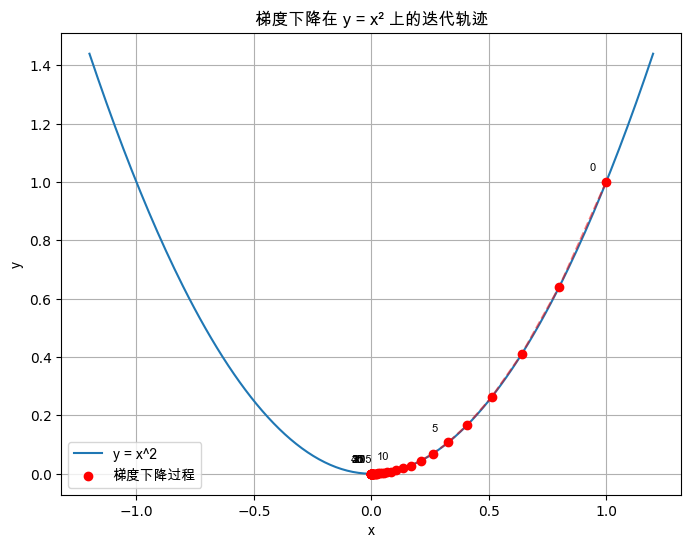

In [22]:
# 目标函数：y = x**2。起始值 x=1，学习率为0.1，使用 for 循环进行梯度下降，并用 matplotlib 绘制每一步在目标函数上的点（所有备注和图标题均为中文，且指定 macOS 上常见的中文字体）

import matplotlib.pyplot as plt
import numpy as np

# 梯度下降参数设置
x = 1.0  # 初始值
learning_rate = 0.1  # 学习率
num_iterations = 40  # 迭代次数

# 记录每一步的 x 和 y
x_history = [x]
y_history = [x**2]

# 梯度下降主循环
for i in range(num_iterations):
    grad = 2 * x  # 计算梯度
    x = x - learning_rate * grad  # 沿梯度方向更新 x
    x_history.append(x)
    y_history.append(x**2)

print("梯度下降法找到的最小值x为:", x)
print("此时y最小值为:", x**2)

# 绘制目标函数曲线
x_vals = np.linspace(-1.2, 1.2, 200)
y_vals = x_vals**2

plt.figure(figsize=(8, 6))

# 指定 macOS 通常存在的中文字体（如苹方、华文黑体、黑体等，按优先级处理）
mac_fonts = ['PingFang SC', 'Heiti SC', 'STHeiti', 'Hiragino Sans GB', 'SimHei', 'Arial Unicode MS']
from matplotlib import font_manager
font_path = None
for font_name in mac_fonts:
    font_files = font_manager.findSystemFonts(fontpaths=None, fontext='ttf')
    # 遍历字体文件，排除已损坏或不可加载的字体，找到第一个可用的中文字体
    for fp in font_files:
        try:
            font_prop = font_manager.FontProperties(fname=fp)
            if font_name == font_prop.get_name():
                font_path = font_name
                break
        except Exception as e:
            continue  # 如果字体加载失败，则跳过该字体

if font_path is None:
    font_path = 'sans-serif'  # 如果都找不到，降级为无衬线字体

plt.plot(x_vals, y_vals, label='y = x^2')  # 函数曲线

# 绘制梯度下降每一步
plt.scatter(x_history, y_history, color='red', zorder=3, label='梯度下降过程')
plt.plot(x_history, y_history, color='red', linestyle="--", alpha=0.5)

# 标注关键迭代点（避免重叠）
for i, (x_p, y_p) in enumerate(zip(x_history, y_history)):
    if i % 5 == 0 or i == len(x_history)-1:
        plt.annotate(f"{i}", (x_p, y_p), textcoords="offset points", xytext=(-10,8), ha='center', fontsize=8, fontname=font_path)

plt.xlabel("x", fontname=font_path)  # x 轴标签
plt.ylabel("y", fontname=font_path)  # y 轴标签
plt.title("梯度下降在 y = x² 上的迭代轨迹", fontname=font_path)  # 图像标题指定字体
plt.legend(prop={'family': font_path})
plt.grid(True)
plt.show()

In [24]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. 加载加利福尼亚房价数据集
cali = fetch_california_housing(data_home='./data')
X, y = cali.data, cali.target

# 2. 分割为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 对特征进行归一化（标准化处理）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 用sklearn自带的梯度下降（SGDRegressor）进行拟合
# SGDRegressor的主要入参说明如下：
# - loss: 损失函数类型，回归默认是'squared_error'
# - penalty: 正则化类型，'l2'、'l1'、'elasticnet'等，默认'l2'
# - alpha: 正则化强度，默认0.0001
# - l1_ratio: elasticnet混合参数，仅在penalty='elasticnet'下有意义
# - fit_intercept: 是否拟合截距，默认True
# - max_iter: 最大迭代次数
# - tol: 损失收敛容忍度，若损失变化小于该值则提前停止
# - shuffle: 每次迭代前是否打乱训练数据，默认True
# - verbose: 决定训练过程是否输出详细信息，数字越大输出越多信息，默认0
# - epsilon: epsilon-Insensitive 损失参数，仅对'epsilon_insensitive'和'squared_epsilon_insensitive'有效
# - random_state: 随机种子
# - learning_rate: 学习率调度方式，'constant'、'optimal'、'invscaling'、'adaptive'等
# - eta0: 初始学习率
# - power_t: 在learning_rate='invscaling'时控制下降速度
# - early_stopping: 是否自动验证并提前终止
# - validation_fraction: 作为验证早停的训练集比例
# - n_iter_no_change: 容忍多少次没有提升才提前终止
# - warm_start: 若为True则后续调用fit会从上次结果继续
# 详细参数含义可查阅官方文档：https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html
sgd_reg = SGDRegressor(
    max_iter=2000,        # 最大迭代次数
    tol=1e-3,             # 收敛容忍度
    random_state=42       # 随机种子，保证结果可复现
)
sgd_reg.fit(X_train_scaled, y_train)

# 5. 在测试集和训练集上评估模型
y_train_pred = sgd_reg.predict(X_train_scaled)
y_test_pred = sgd_reg.predict(X_test_scaled)

print("训练集MSE:", mean_squared_error(y_train, y_train_pred))
print("测试集MSE:", mean_squared_error(y_test, y_test_pred))
print("训练集R^2:", r2_score(y_train, y_train_pred))
print("测试集R^2:", r2_score(y_test, y_test_pred))

训练集MSE: 0.5283815816080336
测试集MSE: 0.5505987775857769
训练集R^2: 0.6047350435935549
测试集R^2: 0.5798267665069696
